In [132]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT
from python_files import ETLM_code as ETLMC
from python_files import LETLM_code as LETLMC
from python_files import IETLM_code as IETLMC


torch.set_default_dtype(torch.float64)







The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [134]:
#  We first need to set our parameters
N = 40 # The number of grid points
dx = 1 # The spacing
F_96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  30   #14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_96)


In [135]:
# We will start by defining our error function
def norm_error(x_g,x_pert, model, M, model_parameters):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = x_out_pert - x_out_unpert - torch.matmul(M, x_pert)
    return diff


def normalisor(x_g, x_pert, model_parameters, M, model):
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    norm = x_out_pert - x_out_unpert
    return norm

def alt_TLM_test(x_g, x_pert, model_parameters, M, model):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = sum(abs(x_out_pert - x_out_unpert - torch.matmul(M, x_pert)))
    average = sum(abs(x_pert))
    return (diff/average)/N
    

# We will now define a very quick generic TLM test that will be used for the multistep TLM test 
def generic_TLM_test(diff, norm):
    error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))
    return error

In [136]:
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results = []
trials = 50
spin_up_time = 1000
for i in perturbations:
    sd = 10**(-i) #(-1*perturbations[i])
    print(sd)
    ensemble_size = 150
    model = bf.rk4_L96
    # model = test_model

    # We first need to spin up the model
    x_0 = torch.randn(N,1)
    x = ETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
    x_g = x
    ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)

    # plt.imshow(ETLM,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("ETLM")
    # plt.show()
    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, ETLM, model_parameters)
        norm = normalisor(x_g, x_pert, model_parameters, ETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, ETLM, model)
    results.append(error/trials)


    

    

1


100%|██████████| 150/150 [00:00<00:00, 10055.55it/s]


0.1


100%|██████████| 150/150 [00:00<00:00, 10449.36it/s]

0.01


...

100%|██████████| 150/150 [00:00<00:00, 10611.86it/s]


1e-09


100%|██████████| 150/150 [00:00<00:00, 10682.86it/s]


1e-10


100%|██████████| 150/150 [00:00<00:00, 10274.78it/s]


In [137]:
# We will now do the same for the Jacobian generated by the pytorch function 
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_pytorch = []
trials = 50
spin_up_time = 1000
for i in perturbations:
    sd = 10**(-1* i)
    ensemble_size = 150
    model = bf.rk4_L96

    # We first need to spin up the model
    # x_0 = torch.randn(N)
    # x = ETLMC. spin_up(x, model_parameters, model)
    # x_g = x
    # ETLM, Chi, X =ETLMC.ETLM_generator(ensemble_size, sd, x, model_parameters, model)
    
    x_0 = torch.randn(N,1)
    x = ETLMC.spin_up(x, model_parameters, model, spin_up_time)
    x_g = x

    y = x_g.clone().detach().requires_grad_(True)

    J = torch.autograd.functional.jacobian(lambda y: model(y, model_parameters),y).squeeze()

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, J, model_parameters)
        norm = normalisor(x_g, x_pert,  model_parameters, J, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, J, model)
    results_pytorch.append(error/trials)

In [138]:
# We will now run the LETLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations

perturbations = [0,1,2,3,4,5,6,7,8,9,10]
# perturbations = [7]

results_local = []
trials = 50
spin_up_time = 1000
x_0 = torch.randn(N,1)
x = LETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x.clone()
for i in perturbations:
    sd = 10**(-i) #(-1*perturbations[i])
    print('sd:',sd)
    ensemble_size = 16
    model = bf.rk4_L96

    # model = test_model

    # We first need to spin up the model
    
    LETLM = LETLMC.LETLM_generator(ensemble_size, sd, x, model_parameters, model)

    # plt.imshow(LETLM,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("LETLM")
    # plt.show()
    # print(LETLM[i,:])
    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, LETLM, model_parameters)
        norm = normalisor(x_g, x_pert, model_parameters, LETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, LETLM, model)
        # print(error)
        # print(error.shape)
    results_local.append(error/trials)
    

    

sd: 1


100%|██████████| 16/16 [00:00<00:00, 8420.18it/s]


sd: 0.1


100%|██████████| 16/16 [00:00<00:00, 8134.41it/s]


sd: 0.01


...

100%|██████████| 16/16 [00:00<00:00, 7955.06it/s]


sd: 1e-09


100%|██████████| 16/16 [00:00<00:00, 8412.79it/s]


sd: 1e-10


100%|██████████| 16/16 [00:00<00:00, 8101.02it/s]


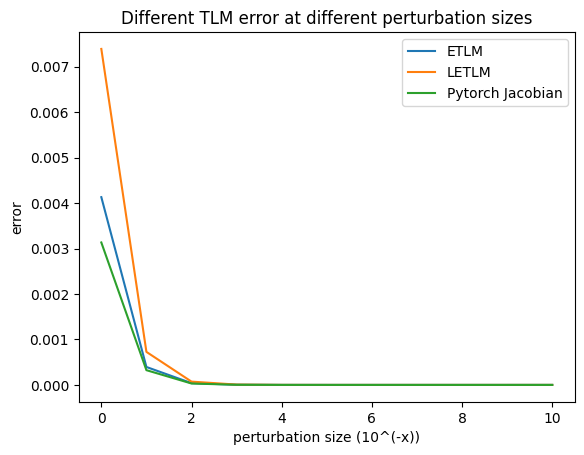

In [139]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()

plt.show()

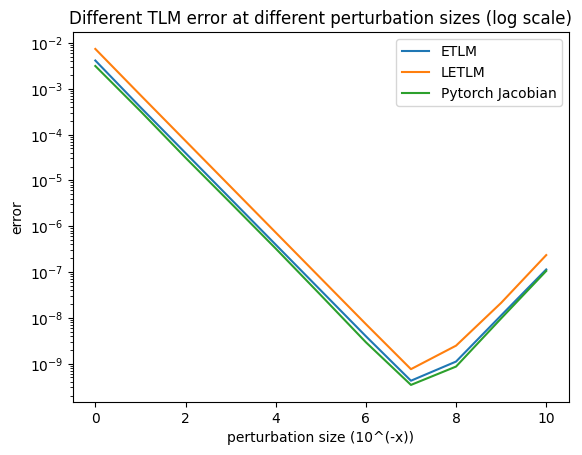

In [140]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

In [141]:
# We will now run the LETLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations

perturbations = [0,1,2,3,4,5,6,7,8,9,10]
# perturbations = [7]

results_IETLM = []
trials = 50
spin_up_time = 1000
x_0 = torch.randn(N,1)
x = IETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x.clone()
for i in perturbations:
    sd = 10**(-i) #(-1*perturbations[i])
    # print('sd:',sd)
    ensemble_size = 30
    model = bf.rk4_L96

    # model = test_model

    # We first need to spin up the model
    
    N_tilde, L_tilde = IETLMC.IETLM_generator(ensemble_size, sd, x, model_parameters, model)
    IETLM = torch.inverse(N_tilde) @ L_tilde

    # plt.imshow(LETLM,aspect='auto', cmap='viridis')
    # plt.colorbar(label='Value')
    # plt.title("LETLM")
    # plt.show()
    # print(LETLM[i,:])
    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j**2)
        x_pert = torch.randn(N,1) * sd

        diff = norm_error(x_g, x_pert, model, IETLM, model_parameters)
        norm = normalisor(x_g, x_pert, model_parameters, IETLM, model)

        TLM_test_result = generic_TLM_test(diff, norm)
        error += alt_TLM_test(x_g, x_pert, model_parameters, IETLM, model)
        # print(error)
        # print(error.shape)
    results_IETLM.append(error/trials)
    

    

100%|██████████| 30/30 [00:00<00:00, 9673.95it/s]


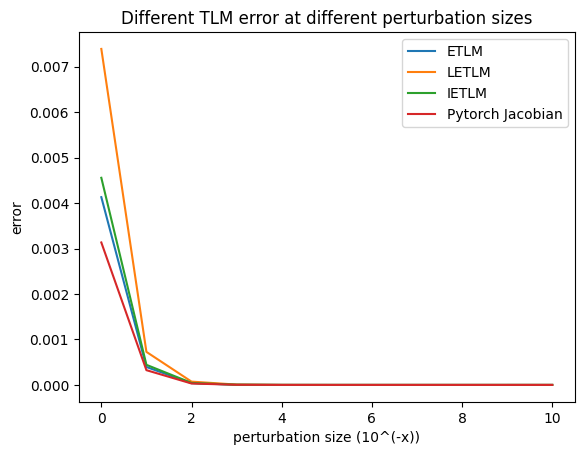

In [142]:
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_IETLM,label = 'IETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )



plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes')
plt.legend()

plt.show()

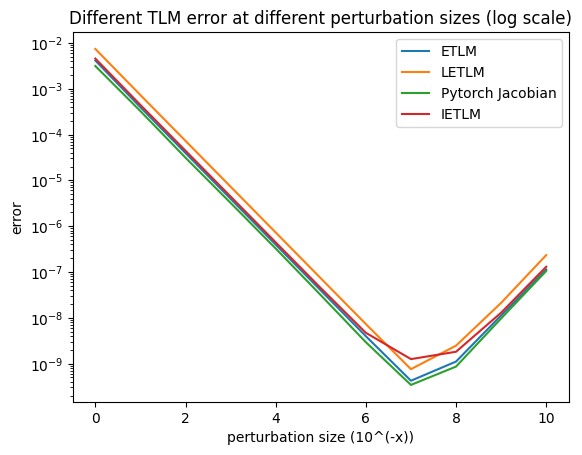

In [143]:
plt.yscale('log')
plt.plot(perturbations, results,label = 'ETLM' )
plt.plot(perturbations, results_local,label = 'LETLM' )
plt.plot(perturbations, results_pytorch,label = 'Pytorch Jacobian' )
plt.plot(perturbations, results_IETLM,label = 'IETLM' )
plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('Different TLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()

In [144]:
# I will now attempt to recreate the plots for Bishop and Eizenberg
# We start by generating a random normal noise vector
spin_up_time = 1000
(N, dx, dt, alpha, beta, F_L96) = model_parameters
 # we now run the model to spin up the model
x_in = torch.rand((N,1))
results = x_in
for i in range(spin_up_time):
    x_out = model(x_in, model_parameters)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out

In [151]:
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_96)
ensemble_size = 25
model = bf.rk4_L96
spin_up_time = 1000
perturbation_size = 10**(-7)
x_values = np.arange(1, N+1)  




model_steps = 20
sd = 10**(-7)
test_pert = torch.randn((N,1))*sd
test_pert_ETLM = test_pert
test_pert_LETLM = test_pert
test_pert_IETLM = test_pert
test_pert_Jac = test_pert



for i in range(model_steps):
    # we first generate the LETLM, IETLM, ETLM and Jacobian for each time step 
    plt.title(f' Lorenz 96 after time step = {i:.2f}')
    plt.plot(x_values, test_pert_ETLM, label = 'ETLM')
    plt.plot(x_values, test_pert_LETLM, label = 'LETLM')
    plt.plot(x_values, test_pert_IETLM, label = 'IETLM')
    plt.plot(x_values, test_pert_Jac, label = 'Jacobian')
    plt.plot(x_values, test_pert, label = 'Model')
    plt.legend()
    # plt.savefig(f'/Users/imilesfine/PhD Work/2026/Lorenz_basic/model_run/plot_{i + 1}.png')
    plt.savefig(f'/Users/imilesfine/PhD_Work/2026/Lorenz_basic/TLM_comp/plot_{i + 1}.png')
    # /Users/imilesfine/PhD Work2026/Lorenz_basic
    plt.clf()

    

    # We now generate the TLMs for the current state vector

    # We start with the LETLM
    ensemble_size = 16
    LETLM = LETLMC.LETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

    # We now the the IETLM
    ensemble_size = 30
    N_tilde, L_tilde = IETLMC.IETLM_generator(ensemble_size, sd, x_out, model_parameters, model)
    IETLM = torch.inverse(N_tilde) @ L_tilde

    # We now do the ETLM
    ensemble_size = 90
    ETLM, Chi, X  = ETLMC.ETLM_generator(ensemble_size, sd, x_out, model_parameters, model)

    # We finally do the Pytorch autograd function
    y = x_out.squeeze().clone().detach().requires_grad_(True)
    Jac = torch.autograd.functional.jacobian(lambda y: model(y, model_parameters), y)   
    # print(Jac.shape)

    # We now use this to calculate the values of the next perturbation
    test_pert_ETLM = ETLM @ test_pert_ETLM
    test_pert_LETLM = LETLM @ test_pert_LETLM
    test_pert_IETLM = IETLM @ test_pert_IETLM
    test_pert_Jac =  Jac @ test_pert_Jac

    test_pert = model(x_out + test_pert, model_parameters) - model(x_out, model_parameters)


    # We then run the model again to get to the next time step
    x_in = x_out
    x_out = model(x_in, model_parameters)






    


100%|██████████| 90/90 [00:00<00:00, 10373.67it/s]


<Figure size 640x480 with 0 Axes>